In [1]:
%load_ext autoreload
%autoreload 2
from mGST.low_level_jit import cost_function_jax_mps
from mGST.utility_functions_comparisons import get_full_mgst_parameters_from_configuration, GSTConfiguration, get_compressed_perturbed_rep_from_mgst, get_compressed_perturbed_kraus_from_superop, kraus_tensor_to_mgst, target_kraus_tensor_from_configuration
from mGST.trust_region import run_riemannian_optimization, estimate_noise_floor_threshold
from mGST.typing import TrustRegionOptions, OperatorSchedule
from mGST.visualization import plot_cost_function

import jax.numpy as jnp

backend = "iqmfakeapollo"

/Users/emiliano.godinez/.pyenv/versions/qcvv-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Setup (parameters, configuration and initial tensors)

In [2]:
depth = 7
num_shots = 1000
num_seq_2q = 900
kraus_rank_4 = 4
kraus_rank_16 = 16

num_qubits_2 = 2
dim_2q = 2 ** num_qubits_2
state_rank_2q = dim_2q
povm_rank_2q = dim_2q

# Running experiment

In [3]:
# This will be reused for all rank's in 2Q system. Since the rank passsed here is just symbolic.
# This rank is only accesed later from the data set to factorize into kraus psd (we do this manually outside)
Q2_GST = GSTConfiguration(
    qubit_layouts=[[0, 1]],
    gate_set="2QXYICZ",
    num_circuits=num_seq_2q,
    shots=num_shots,
    rank=1,
)

kraus_tensor_mgst_2q_rank_1, kraus_mgst_2q_rank_1, povm_mgst_2q, state_mgst_2q, prob_matrix_2q, indices_list_2q = get_full_mgst_parameters_from_configuration(
    Q2_GST, backend, only_jax_variables=True
)

2026-04-10 19:37:43,938 - iqm.benchmarks.logging_config - INFO - Generating 900 random GST circuits
2026-04-10 19:37:44,660 - iqm.benchmarks.logging_config - INFO - Will transpile all 900 circuits according to fixed physical layout
2026-04-10 19:37:44,991 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2026-04-10 19:37:48,130 - iqm.benchmarks.logging_config - INFO - Submitting batch with 900 circuits corresponding to qubits [0, 1]
2026-04-10 19:37:48,140 - iqm.benchmarks.logging_config - INFO - Stored jobs for 1 layouts in dataset
2026-04-10 19:37:48,199 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2026-04-10 19:37:48,261 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
2026-04-10 19:37:49,257 - iqm.benchmarks.logging_config - INFO - Adding counts to dataset
2026-04-10 19:37:51,140 - iqm.benchmarks.logging_config - INFO - Run complet

In [4]:
povm_psd_init_2q, state_psd_init_2q = get_compressed_perturbed_rep_from_mgst(povm_mgst_2q, state_mgst_2q)
cost_fn_kwargs_2q = {
    "indices_list": indices_list_2q,
    "prob_matrix": prob_matrix_2q,
    "jit": True,
}

In [6]:
# Obtain unperturbed Kraus
kraus_tensor_target = target_kraus_tensor_from_configuration(Q2_GST, backend)
kraus_superop_target = kraus_tensor_to_mgst(kraus_tensor_target)
kraus_superop_target.shape, kraus_tensor_target.shape

((6, 16, 16), (6, 1, 4, 4))

In [8]:
# Now let's get the higher rank ones
kraus_tensor_init_2q_rank_16 = get_compressed_perturbed_kraus_from_superop(superop=kraus_superop_target, rank=16, seed=42)["kraus_tensor"]

# Gathering initial operators

In [9]:
init_operators_jax_2q_rank_16 = {
    "kraus_tensor_init": kraus_tensor_init_2q_rank_16,
    "povm_psd_init": povm_psd_init_2q,
    "state_psd_init": state_psd_init_2q,
}

initial_cost_value_rank_16 = cost_function_jax_mps(kraus_tensor_init_2q_rank_16, povm_psd_init_2q, state_psd_init_2q, **cost_fn_kwargs_2q)
print("Initial cost value (rank 16):", initial_cost_value_rank_16)

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 7 the new count changed to: 3
at iteration 43 the new count changed to: 4
at iteration 110 the new count changed to: 5
at iteration 178 the new count changed to: 6
at iteration 246 the new count changed to: 7
at iteration 314 the new count changed to: 8
at iteration 382 the new count changed to: 9
at iteration 450 the new count changed to: 10
at iteration 525 the new count changed to: 11
at iteration 600 the new count changed to: 12
at iteration 675 the new count changed to: 13
at iteration 750 the new count changed to: 14
at iteration 825 the new count changed to: 15
Initial cost value (rank 16): 0.001433826722140433


In [13]:
[op.shape for op in init_operators_jax_2q_rank_16.values()]

[(6, 16, 4, 4), (4, 4, 4), (4, 4)]

# Optimization

## Setup

In [12]:
relative_precision = 1e-5
noise_threshold = estimate_noise_floor_threshold(cost_fn_kwargs_2q["prob_matrix"], num_shots=num_shots, multiplier=1.0)

print("Noise threshold: ", noise_threshold)

num_iterations_outer = 5
num_iterations_tr = 10
num_iterations_cg = 10
tol_grad = 1e-4
kappa = 1/10
theta = 1 # before by mistake we set it to 0.5 (WRONG)

tr_schedule_verbose = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=True, verbose_cg=True, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad, kappa_cg=kappa, theta_cg=theta))

optimization_schedule_all_tr = {
    "kraus": tr_schedule_verbose,
    "povm": tr_schedule_verbose,
    "state": tr_schedule_verbose
}
optimization_schedule_all_tr

Noise threshold:  0.00015645938722222218


{'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
 'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
 'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))])}

## Run

In [23]:
optimized_operators, cost_fn_history = run_riemannian_optimization(
    **init_operators_jax_2q_rank_16,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs_2q,
    num_iterations=num_iterations_outer,
    optimization_schedule=optimization_schedule_all_tr,
    save_intermediate_cost_values=True,
    relative_precision=relative_precision,
    noise_threshold=None, # do not stop if we go below this.
    verbose=True,
)

🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-05 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 1.433827e-03. |r∇f(x)|: 2.339607e-03. Radius: 1.00e-01
TCG finished after: 4/10 iters. 
 Reason: (tCG) Stopping criteria met 🛑. |r_k| = 2.70e-06
---------------------------------------
TR Iteration: 1. f(x): 1.364776e-03. |r∇f(x)|: 1.189691e-05. Radius: 1.00e-01
TCG finished after: 5/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
(RTR) Stopping criteria met. 🚨 |r∇f(x)|/|r∇f(x_0)| = 9.534928e-06
Optimization finished ✅. 
 Iters: 2. f(x): 1.364775e-03. |r∇f(x)|: 2.230798e-08. Radius: 2.00e-01. Rejections: 0

 🎯 [Povm] Relative change in cost function value: 6.90e-05. Target: 1.00e-05.
🚀 TR started for operat

## visualize trajecttory

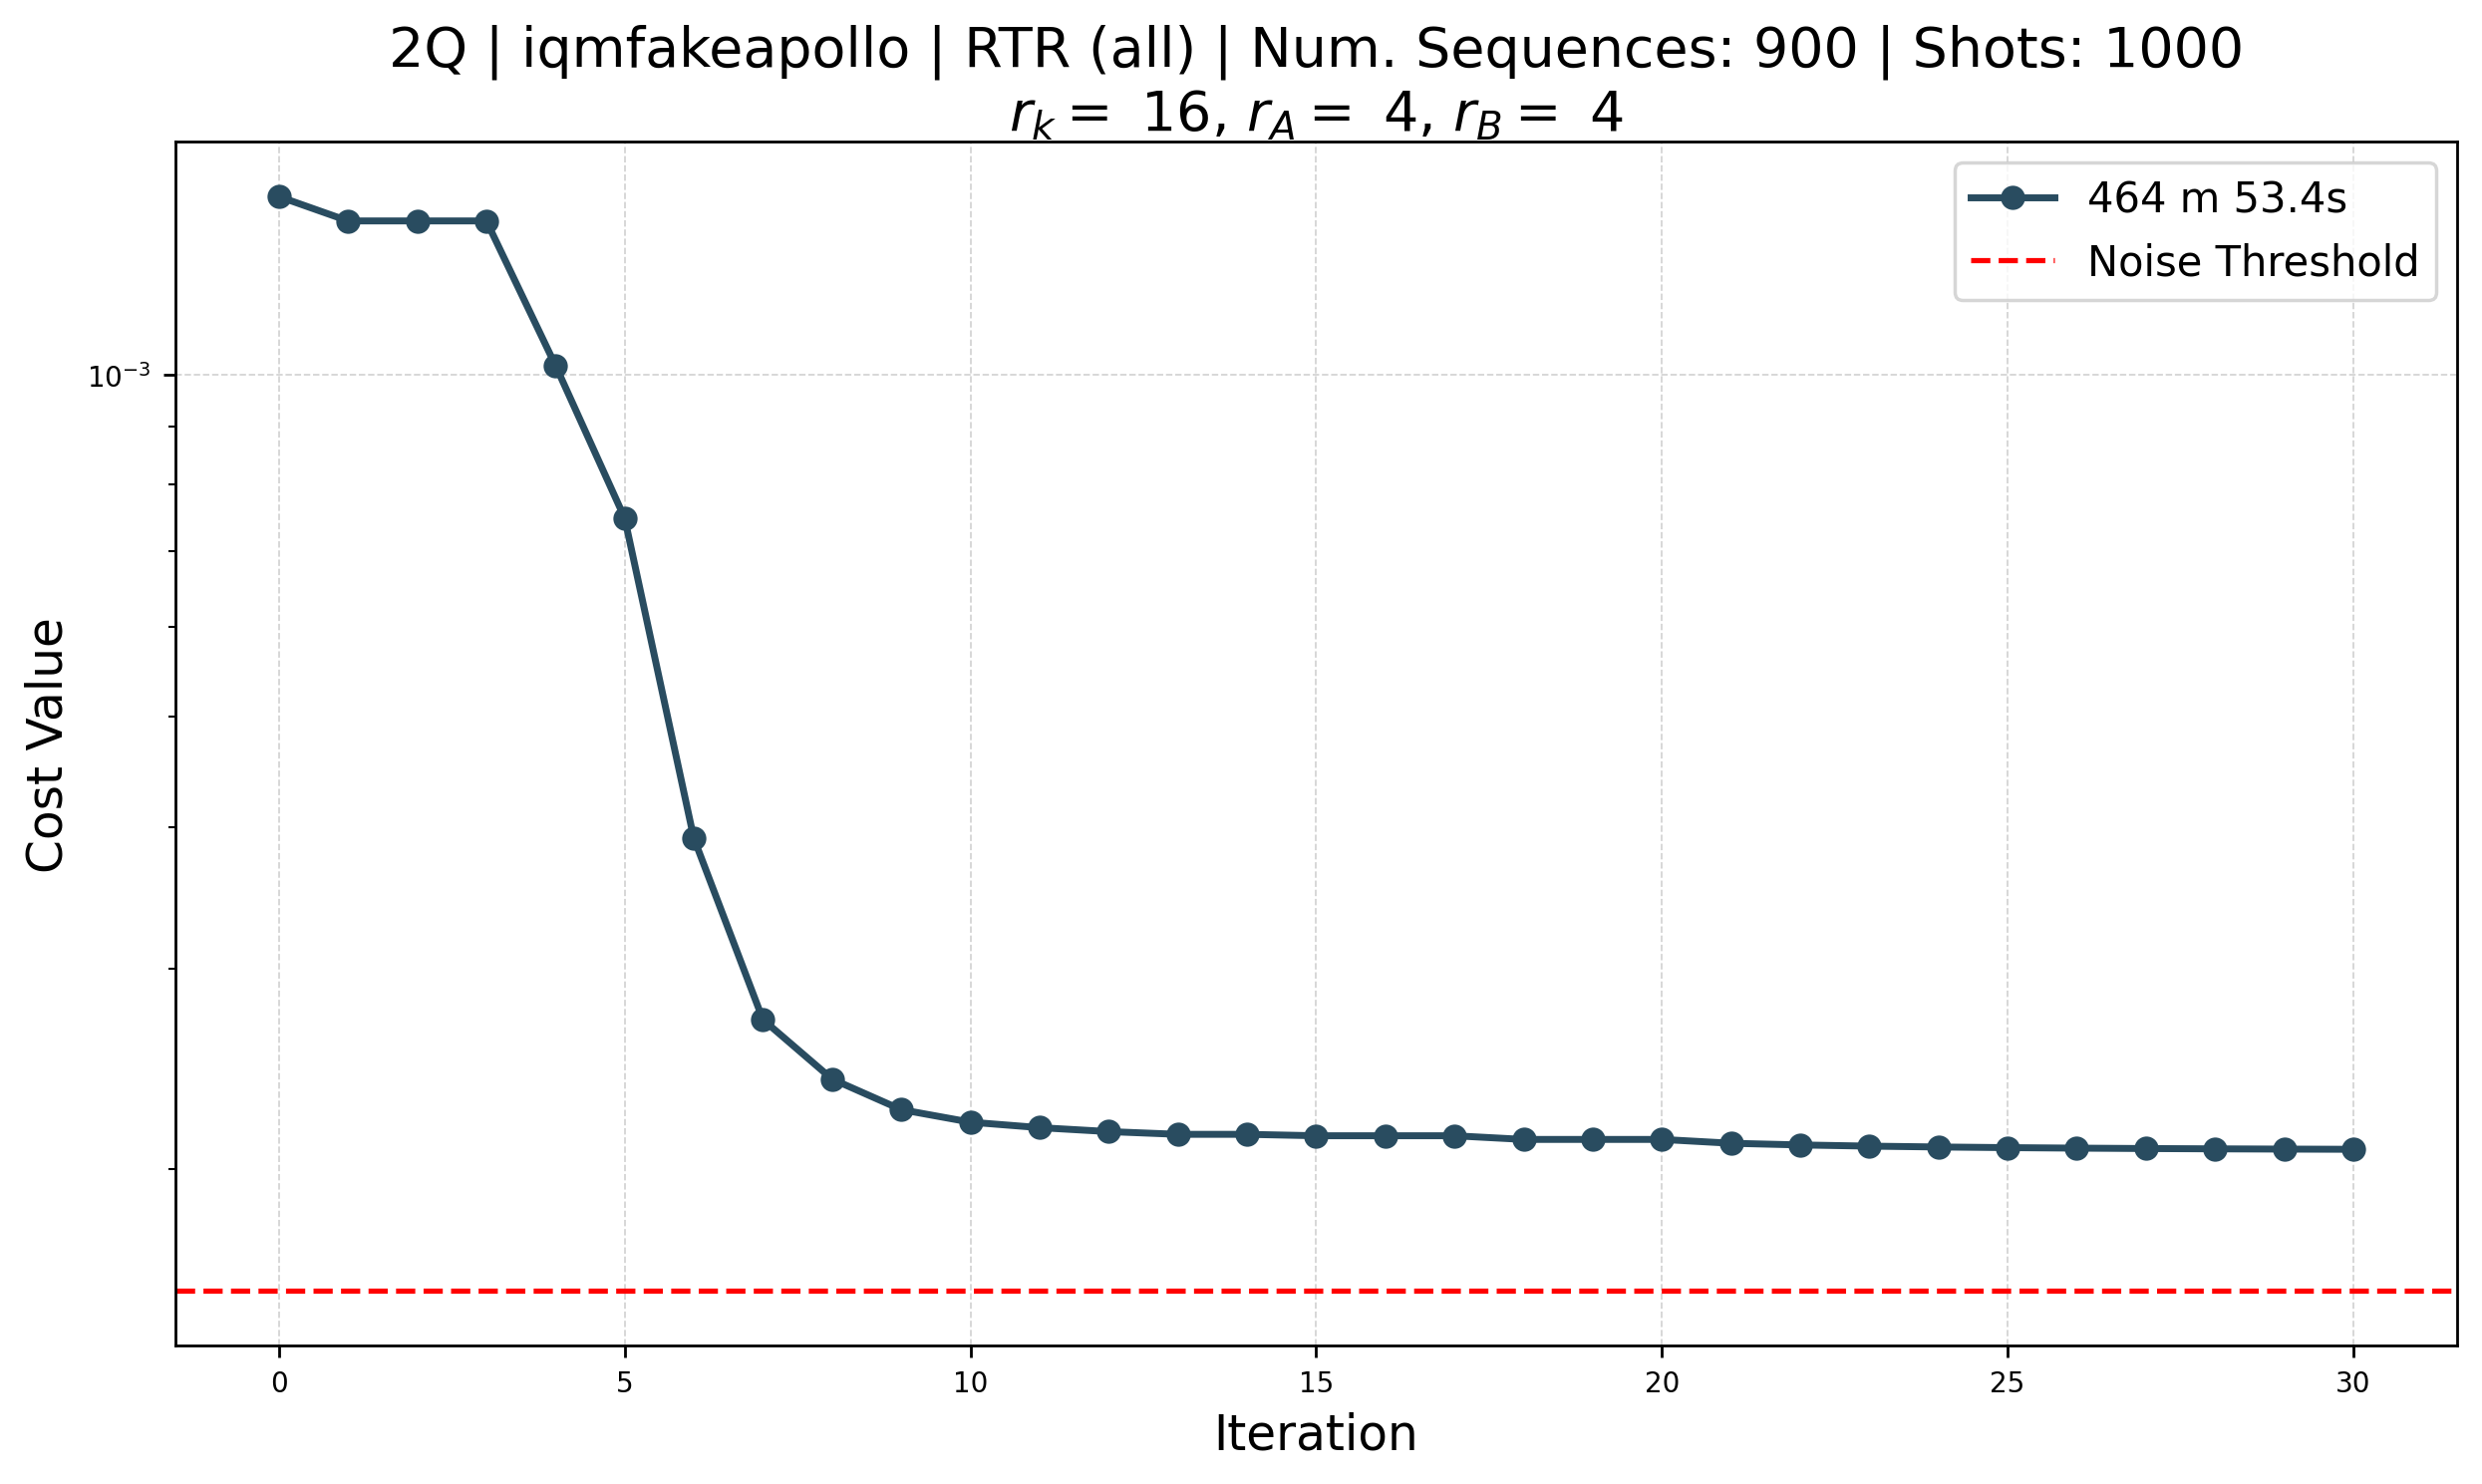

In [24]:
plot_cost_function(
    cost_array=[cost_fn_history],
    labels=[r"464 m 53.4s"],
    comparison_yline=noise_threshold,
    comparison_label="Noise Threshold",
    title=f"{num_qubits_2}Q | {backend} | RTR (all) | Num. Sequences: {num_seq_2q} | Shots: {num_shots}" + "\n" + rf"$r_k =$ {kraus_rank_16}, $r_A =$ {dim_2q}, $r_B =$ {dim_2q}"
)

# Vertical generators

# At initial point